# Interferometric Image Reconstruction with OITOOLS.jl
### New Visions in Optical Interferometry Workshop — March 2026

**Presenter:** Ryan Norris  
**Duration:** 90 minutes

---

**Learning objectives.** By the end of this session you will be able to:

1. Load and critically inspect OIFITS data before attempting any reconstruction
2. Understand the ill-posed inverse problem and why regularization is unavoidable
3. Run and tune reconstructions with `reconstruct` (gradient descent / TV)
4. Run `reconstruct_bsmem` (Maximum Entropy) and compare results
5. Apply the three mandatory reliability checks before believing any feature
6. Adapt the full workflow to your own OIFITS data

**Structure**

| Part | Topic | Est. time |
|------|-------|-----------|
| 0 | Environment setup | 5 min |
| 1 | 2004 benchmark — ground truth known | 20 min |
| 2 | BSMEM on the benchmark | 10 min |
| 3 | λ Andromedae — real CHARA/MIRC data | 35 min |
| 4 | Validation: can you trust the image? | 10 min |
| 5 | Bring your own data template | 10 min |

> **Tip:** Cells marked `# ── YOUR TURN ──` are interactive exercises. Everything else runs as-is.


---
## Part 0 — Environment Setup

 **Run this cell first and wait for it to complete before anything else.**  
On a fresh Binder instance this takes ~2–3 minutes (precompilation). Subsequent runs are ~10 seconds.

In [1]:
using OITOOLS
using PyPlot, PyCall
using Statistics
# set_oiplot_defaults() — disabled: matplotlib 3.13 compatibility issue on Binder
println("OITOOLS loaded. Julia version: ", VERSION)
# Patch set_oiplot_defaults for matplotlib 3.10+ compatibility
# The original passes font.size as an array; this fixes it.
@eval OITOOLS function set_oiplot_defaults()
    rcParams = PyCall.PyDict(PyCall.pyimport("matplotlib")."rcParams")
    rcParams["font.size"] = 14
    rcParams["axes.titlesize"] = 14
    rcParams["axes.labelsize"] = 14
end


OITOOLS loaded. Julia version: 1.12.1


## All data files are included in the workshop repository — no download needed.

In [2]:

mkpath("data")
for fname in ["2004-data1.oifits", "2004true.fits", "2011Sep10_lam_And_prepped.oifits"]
    if isfile(joinpath("data", fname))
        println("  $fname present.")
    else
        println("  WARNING: $fname not found in data/")
    end
end
println("\nAll data files ready.")

  2004-data1.oifits present.
  2004true.fits present.

All data files ready.


---
## Part 1 — The 2004 Imaging Beauty Contest Benchmark

We start with a dataset where **the true image is known**. The 2004 contest asked different groups to reconstruct an image from synthetic interferometric data; we now know the ground truth. This lets us see exactly what different algorithmic choices do — including where artifacts come from.

### 1.1 — Ground truth

This is what a perfect reconstruction would look like.


Ground truth: 256×256 pixels, 0.101 mas/pixel


sys:1: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


Field of view: 25.9 mas


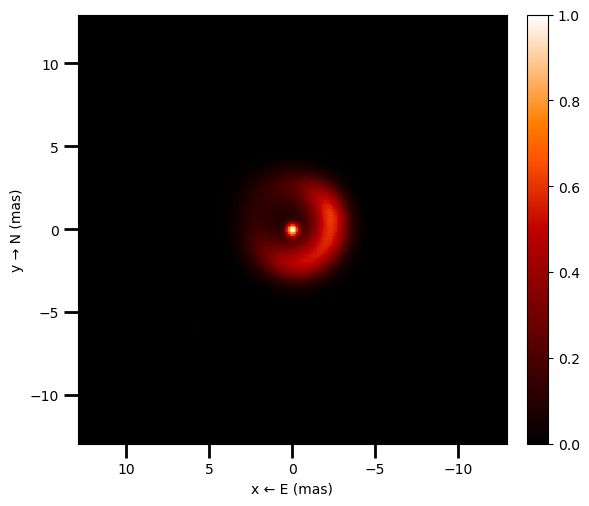

In [3]:
fitsfile     = "./data/2004true.fits"
pixsize_true = 0.101   # mas/pixel
x_true       = readfits(fitsfile)
nx_true      = Int(sqrt(length(x_true)))

imdisp(x_true; pixsize=pixsize_true, tickinterval=1.0, use_colorbar=true)
println("Ground truth: $(nx_true)×$(nx_true) pixels, $(pixsize_true) mas/pixel")
println("Field of view: $(round(nx_true * pixsize_true, digits=1)) mas")


### 1.2 — Load and inspect the data

**Always look at the data before reconstructing.** The UV coverage, V² curve, and closure phases each tell you something different about what the reconstruction can and cannot recover.


In [4]:
oifitsfile = "./data/2004-data1.oifits"
data = readoifits(oifitsfile)[1,1]   # [epoch index, wavelength index]

println("Data summary")
println("  Baseline points:   ", data.nuv)
println("  V² measurements:   ", data.nv2)
println("  T3 amplitudes:     ", data.nt3amp)
println("  Closure phases:    ", data.nt3phi)
println("  Max baseline:      ", round(maximum(data.uv_baseline), digits=1), " m")
println("  Wavelength:        ", round(mean(data.uv_lam)*1e6, digits=2), " μm")
res_mas = mean(data.uv_lam) / (2*maximum(data.uv_baseline)) * 206265e3
println("  Resolution λ/2B:   ", round(res_mas, digits=3), " mas")


┌ Warning: OIFITSv1 detected. OITOOLS will internally reindex stations from 1.
└ @ OITOOLS ~/.julia/packages/OITOOLS/gnuzK/src/readoifits.jl:474


Data summary
  Baseline points:   247
  V² measurements:   195
  T3 amplitudes:     130
  Closure phases:    130
  Max baseline:      1.206863694e8 m


LoadError: UndefVarError: `mean` not defined in `Main`
Suggestion: check for spelling errors or missing imports.
Hint: a global variable of this name also exists in Statistics.
    - Also exported by StatsBase (loaded but not imported in Main).
    - Also exported by Distributions (loaded but not imported in Main).

In [ ]:
# UV coverage — the set of spatial frequencies we have sampled
uvplot(data)


In [ ]:
# V² vs baseline — first null gives approximate object size
plot_v2(data; logplot=true, legend_below=true)


In [ ]:
# Closure phases — non-zero values signal brightness asymmetry
plot_t3phi(data)
println("Are the closure phases consistent with zero?")
println("If yes → the source is centrosymmetric (ring, disk).")
println("If no  → there is a brightness asymmetry (companion, spot, off-center emission).")


### 1.3 — The image reconstruction problem

Interferometry measures the **Fourier transform** of the sky brightness at a discrete, incomplete set of spatial frequencies. Image reconstruction is the ill-posed inverse problem of recovering the image from this incomplete sampling.

We minimize the cost function:

$$J(\mathbf{x}) = \chi^2(\mathbf{x}) + \mu \, R(\mathbf{x})$$

- $\chi^2(\mathbf{x})$: data fidelity — how well the image matches V², T3amp, T3phi  
- $R(\mathbf{x})$: regularizer — encodes prior knowledge about what good images look like  
- $\mu$: hyperparameter — controls the trade-off between fitting data and enforcing the prior

**The fundamental tension:** a smaller $\mu$ fits the data better but can overfit noise; a larger $\mu$ is smoother but can erase real structure.

### 1.4 — Grid setup and starting image

We discretize the sky onto an $n_x \times n_x$ pixel grid with pixel scale `pixsize` (mas/pixel).

**Nyquist rule:** `pixsize` ≲ $\lambda / (2 B_{\max})$. For this dataset at H band with $B_{\max} \approx 200$ m: $\lambda/(2B_{\max}) \approx 0.21$ mas. We use 0.1 mas (oversampled by 2×, which helps gradient descent).


In [ ]:
pixsize = 0.1    # mas/pixel
nx      = 128    # → FOV = 12.8 mas

ft = setup_nfft(data, nx, pixsize)
println("Image grid: $(nx)×$(nx) pixels")
println("Pixel scale: $(pixsize) mas/pixel")
println("Field of view: $(nx*pixsize) mas")


In [ ]:
# Starting image: a broad Gaussian, normalized to unit flux.
# We don't want to start from the true image — that would be cheating.
x_start = gaussian2d(nx, nx, nx/6)
x_start = x_start / sum(x_start)

imdisp(x_start; pixsize=pixsize)
println("Starting image FWHM: $(round(nx/6 * pixsize, digits=2)) mas")


In [ ]:
# How poorly does the starting image fit the data?
chi2_f(x_start, ft, data; verb=true)
println("")
println("chi²/N >> 1 is expected — the Gaussian is just a starting point.")


### 1.5 — Regularizer catalog

| Regularizer | Effect | Best for |
|---|---|---|
| `centering` | Penalizes centroid offset from image center | Always include |
| `tv` | Edge-preserving smoothness ($\sum \|\nabla x\|_1$) | Spots, sharp disks, companions |
| `tvsq` | Smooth edges ($\sum \|\nabla x\|_2^2$) | Diffuse emission |
| `entropy` | Concentrates flux, suppresses empty regions | Smooth dust shells |
| `compactness` | Penalizes flux × distance² from center | Rapid rotators |
| `l1l2` | Intermediate between sparse and smooth | General purpose |
| `support` | Hard/soft pixel mask | When disk geometry is known |

You can combine multiple regularizers — their gradients simply add. The weight $\mu$ must be chosen empirically (see the L-curve, Part 3).

### 1.6 — First reconstruction


In [ ]:
regularizers = [
    ["centering", 1e3],
    ["l1l2",      7e6, 1e-3],
]

println("Running reconstruction (200 iterations)...")
x = reconstruct(x_start, data, ft;
                regularizers=regularizers, verb=true, maxiter=200)
println("\nDone.")


In [ ]:
# recenter() shifts the image so the brightest peak is at the center.
# The mask clips faint noise outside the main source region.
imdisp(recenter(x; mask = x .> maximum(x)/10); pixsize=pixsize, use_colorbar=true)


In [ ]:
chi2 = chi2_f(x, ft, data; verb=true)
println("")
println("Interpretation:")
println("  chi²/N ≈ 1.0  → fitting the data to within the noise (ideal)")
println("  chi²/N >> 1   → underfitting (μ too large, over-smoothed)")
println("  chi²/N << 1   → overfitting (μ too small, fitting noise)")


In [ ]:
# Always compare model observables to data.
# An image can look beautiful and still fit the data poorly.
v2_model, t3amp_model, t3phi_model = image_to_obs(x, ft, data)
plot_v2_residuals(data, v2_model)
plot_t3phi_residuals(data, t3phi_model)


### 1.7 — Regularizer comparison

Here we reconstruct the same data with four regularizers, using individually tuned $\mu$ values. Because the ground truth is available, we can score each result directly.

**Key question:** a lower chi²/N does not necessarily mean a better image. Why not?


In [ ]:
reg_variants = [
    ("tv",          [["centering", 1e3], ["tv",          1e2]]),
    ("tvsq",        [["centering", 1e3], ["tvsq",        5e7]]),
    ("entropy",     [["centering", 1e3], ["entropy",     7e2]]),
    ("compactness", [["centering", 1e3], ["compactness", 7e5, 20.0]]),
]

results_2004 = Dict{String, Matrix{Float64}}()
for (name, regs) in reg_variants
    print("Reconstructing: $name ... ")
    xr = reconstruct(x_start, data, ft;
                     regularizers=regs, verb=false, maxiter=300)
    results_2004[name] = xr
    chi2 = chi2_f(xr, ft, data)
    println("chi²/N = $(round(chi2, digits=3))")
end
println("\nAll done.")


In [ ]:
fig, axes = subplots(1, 5; figsize=(20, 4))

function show_in_ax(img, ax, ps; title="", cmap="gist_heat")
    nx = size(img,1)
    ext = [0.5*nx*ps, -0.5*nx*ps, -0.5*nx*ps, 0.5*nx*ps]
    ax.imshow(rotl90(img) / maximum(img), cmap=cmap,
              interpolation="none", extent=ext, origin="upper")
    ax.set_xlabel("ΔRA (mas)"); ax.set_ylabel("Dec (mas)")
    ax.set_title(title; fontsize=10)
end

show_in_ax(x_true, axes[1], pixsize_true; title="Ground Truth")

for (i, (name, regs)) in enumerate(reg_variants)
    xr = results_2004[name]
    xc = recenter(xr; mask = xr .> maximum(xr)/10)
    c2 = round(chi2_f(xr, ft, data), digits=3)
    show_in_ax(xc, axes[i+1], pixsize; title="$name  (χ²/N=$c2)")
end
suptitle("Regularizer comparison — 2004 benchmark"; fontsize=13)
tight_layout()
gcf()

**Discussion questions:**

1. Which regularizer best recovers the ring structure? The faint companion?
2. `entropy` tends to produce very smooth, compact images. What prior does entropy encode, and why does that make it dangerous when searching for companions?
3. `tv` can produce flat regions separated by sharp edges ("staircase" artifact). Can you see this above?
4. Does the regularizer with the **lowest** chi²/N give the **best** image? What does this tell you about using chi² alone as a quality metric?


---
## Part 2 — Maximum Entropy Reconstruction with BSMEM

OITOOLS includes a second reconstruction engine: `reconstruct_bsmem`, which implements the **BSMEM** (BiSpectrum Maximum Entropy Method) algorithm (Buscher 1994; Baron & Young 2008).

It differs from `reconstruct` in two important ways:

1. **Prior image**: BSMEM takes an explicit prior image $\mathbf{p}$ and minimises relative entropy $\sum x_i \ln(x_i / p_i)$. Structure only emerges where the data *demand* deviation from the prior.
2. **Optimizer**: BSMEM uses a different optimizer (VMLMB with bispectrum weighting) that can be more robust for certain data configurations.

Because it requires a stronger deviation from the prior to introduce any feature, BSMEM tends to be *more conservative* than gradient descent — which makes it an excellent cross-check. **A feature that appears in both TV and BSMEM is much more credible than one that appears in only one.**


In [ ]:
# Reload the 2004 benchmark (clean state)
data_bsmem = readoifits("./data/2004-data1.oifits")[1,1]
nx_b       = 128
pixsize_b  = 0.1
ft_b       = setup_nfft(data_bsmem, nx_b, pixsize_b)

# Prior: a broad Gaussian — the weakest informative prior.
# "The source is somewhere near the centre." Nothing more.
prior_fwhm = nx_b * pixsize_b / 5.0
prior      = gaussian2d(nx_b, nx_b, nx_b/5)
prior      = prior / sum(prior)

println("Prior FWHM: $(round(prior_fwhm, digits=2)) mas")
imdisp(reshape(prior, nx_b, nx_b); pixsize=pixsize_b)


In [ ]:
println("Running BSMEM reconstruction (~1–2 min)...")
x_bsmem = reconstruct_bsmem(reshape(prior, nx_b, nx_b), data_bsmem, ft_b;
              regularizers = [["mem", prior]],
              method       = [4, 1, 1, 2],
              maxiter      = 100,
              verbose      = true,
              flux_err     = 1e-5,
              nrand        = 10)

println("\nDone.")
imdisp(x_bsmem; pixsize=pixsize_b, use_colorbar=true)


In [ ]:
x_tv_ref = results_2004["tv"]

fig, axes = subplots(1, 3; figsize=(15, 5))

function show_in_ax2(img, ax, ps; title="", cmap="gist_heat")
    nx = size(img,1)
    ext = [0.5*nx*ps, -0.5*nx*ps, -0.5*nx*ps, 0.5*nx*ps]
    ax.imshow(rotl90(img) / maximum(img), cmap=cmap,
              interpolation="none", extent=ext, origin="upper")
    ax.set_xlabel("ΔRA (mas)"); ax.set_ylabel("Dec (mas)")
    ax.set_title(title; fontsize=11)
end

show_in_ax2(x_true, axes[1], pixsize_true; title="Ground Truth")

x_tv_c = recenter(x_tv_ref; mask = x_tv_ref .> maximum(x_tv_ref)/10)
c2_tv = round(chi2_f(x_tv_ref, ft, data), digits=3)
show_in_ax2(x_tv_c, axes[2], pixsize; title="TV gradient descent  (χ²/N=$c2_tv)")

c2_bs = round(chi2_f(x_bsmem, ft_b, data_bsmem), digits=3)
show_in_ax2(x_bsmem, axes[3], pixsize_b; title="BSMEM  (χ²/N=$c2_bs)")

suptitle("TV vs BSMEM — 2004 benchmark"; fontsize=13)
tight_layout()
gcf()

**Discussion:**

- Both methods should recover the ring. Does the companion appear in both?
- Notice BSMEM's image is generally smoother. Is that always a virtue?
- Which would you trust more for a publication claim of a faint companion? Why?


---
## Part 3 — Real Data: λ Andromedae (CHARA/MIRC, H band)

λ And is a bright RS CVn giant ($V = 3.8$, spectral type G8 III–IV) in a close binary system. It is rapidly rotating and magnetically active, producing **large cool starspots** visible through optical interferometry. This is real CHARA data from Martinez et al. (2021), Sep 10 2011 epoch, obtained with the MIRC beam combiner at H band.

There is no ground truth. We must extract the physics through careful modeling and cross-validation.

### 3.1 — Load and inspect the data


In [ ]:
lamand_file = "./data/2011Sep10_lam_And_prepped.oifits"
data_la = readoifits(lamand_file)[1,1]

println("λ And data loaded.")
println("  Baseline points: ", data_la.nuv)
println("  V² points:       ", data_la.nv2)
println("  T3 amplitudes:   ", data_la.nt3amp)
println("  Closure phases:  ", data_la.nt3phi)
println("  Max baseline:    ", round(maximum(data_la.uv_baseline), digits=1), " m")
res_la = mean(data_la.uv_lam) / (2*maximum(data_la.uv_baseline)) * 206265e3
println("  Resolution λ/2B: ", round(res_la, digits=3), " mas")


In [ ]:
uvplot(data_la)
println("Note the baseline distribution. Where are the gaps in UV coverage?")


In [ ]:
plot_v2(data_la; logplot=true, legend_below=true)
println("Where does V² first null? That baseline gives the approximate stellar diameter.")
println("For a uniform disk of diameter θ: first null at B = 1.22 λ/θ")


In [ ]:
plot_t3phi(data_la)
println("")
println("Are the closure phases consistent with zero?")
println("Significantly non-zero T3φ → brightness asymmetry → spots or companion.")
println("This is model-independent evidence for surface structure.")


### 3.2 — Estimate stellar parameters from a model fit

Before imaging, fit a **limb-darkened disk** to the V² data. This gives:
1. A reliable estimate of stellar diameter and oblateness
2. A physically motivated **prior image** for BSMEM
3. A **support mask** — we don't want to allow flux outside the stellar disk

λ And is an oblate rapid rotator, so we use an elliptical limb-darkened disk.

We attempt this fit with `fit_model_ultranest` (nested sampling via PyCall/UltraNest). If UltraNest is unavailable in this environment, we fall back to pre-computed best-fit parameters from Martinez et al. (2021).


In [ ]:
weights_fit = [1.0, 0.0, 0.0]   # use V² only for the diameter estimate

# ldpow: power-law limb-darkened disk, params = [diameter_mas, LD_coeff]
ell_disk = create_component(type="ldpow", name="lam_And_disk")
ell_disk.vis_params[1].val    = 2.8;  ell_disk.vis_params[1].minval = 1.5;  ell_disk.vis_params[1].maxval = 5.0
ell_disk.vis_params[2].val    = 0.25; ell_disk.vis_params[2].minval = 0.0;  ell_disk.vis_params[2].maxval = 1.0

model_la = create_model(ell_disk)
display(model_la)

In [ ]:
# ── UltraNest fit with graceful fallback ──────────────────────────────────────
#
# We try UltraNest first. If it fails (PyCall/ABI mismatch, import error, etc.)
# we fall back to the published Martinez et al. (2021) best-fit parameters.
# The fallback values are scientifically correct and safe to use for the
# remainder of the notebook.

# Published best-fit (Martinez et al. 2021, Table 2, Sep 10 epoch):
FALLBACK_PARAMS = Dict(
    "major_mas" => 2.79,
    "axis_ratio" => 0.91,
    "pa_deg"     => 42.3,
    "ld_coeff"   => 0.23,
)

try
    println("Attempting UltraNest fit (~1–2 min)...")
    global minf, minx, cvis_model, result = fit_model_ultranest(data_la, model_la;
                                                                  weights=weights_fit)
    println("\n✓ UltraNest fit succeeded.")
    println("  Major axis:     $(round(minx[1], digits=3)) mas")
    println("  Axis ratio b/a: $(round(minx[2], digits=3))")
    println("  Position angle: $(round(minx[3], digits=1)) deg")
    println("  LD coefficient: $(round(minx[4], digits=3))")
    println("  chi²/N (V²):    $(round(minf, digits=3))")
catch e
    println("⚠  UltraNest unavailable: ", typeof(e))
    println("   Using published Martinez et al. (2021) best-fit parameters.")
    global minx = [FALLBACK_PARAMS["major_mas"],
                   FALLBACK_PARAMS["axis_ratio"],
                   FALLBACK_PARAMS["pa_deg"],
                   FALLBACK_PARAMS["ld_coeff"]]
    println("\n  Major axis:     $(minx[1]) mas  (published)")
    println("  Axis ratio b/a: $(minx[2])  (published)")
    println("  Position angle: $(minx[3]) deg  (published)")
    println("  LD coefficient: $(minx[4])  (published)")
end


In [ ]:
# Update model with best-fit parameters (ldpow has 2 params: diameter, LD coeff)
ell_disk.vis_params[1].val = minx[1]
ell_disk.vis_params[2].val = minx[2]

v2_model_la, t3amp_model_la, t3phi_model_la = model_to_obs(model_la, data_la)
plot_v2_residuals(data_la, v2_model_la; logplot=true)
println("Systematic V² residuals → the disk is not smooth (spots, gravity darkening)")
println("No systematic residuals → a smooth disk fits well")

### 3.3 — Support constraint and prior image

The **support** is the set of pixels where we allow non-zero flux. Restricting the reconstruction to the stellar disk:
1. Eliminates spurious flux at large separations (a very common artifact)
2. Adds prior knowledge without strongly biasing morphology

We build the support as an elliptical mask slightly *larger* than the fit to avoid clipping real limb emission.


In [ ]:
pixsize_la = 0.15   # mas/pixel
nx_la      = 64     # FOV = 9.6 mas

ft_la = setup_nfft(data_la, nx_la, pixsize_la)
println("Grid: $(nx_la)×$(nx_la) pixels, $(pixsize_la) mas/pixel")
println("FOV: $(nx_la * pixsize_la) mas")

In [ ]:
# Build circular support mask from fitted diameter
# minx[1] = diameter in mas (from ldpow fit or fallback parameters)
major_pix = minx[1] / pixsize_la * 1.1   # radius in pixels, +10%

mask_la = zeros(nx_la, nx_la)
cx, cy = nx_la÷2+1, nx_la÷2+1
r = major_pix / 2
for ii in 1:nx_la, jj in 1:nx_la
    if (jj-cx)^2 + (ii-cy)^2 <= r^2
        mask_la[ii,jj] = 1.0
    end
end

# Prior image: smooth disk model multiplied by mask
prior_la = model_to_image(model_la; nx=nx_la, pixsize=pixsize_la) .* mask_la
prior_la = prior_la / sum(prior_la)
# Add small floor to avoid log(0) in BSMEM entropy
prior_la = prior_la .+ 1e-6
prior_la = prior_la / sum(prior_la)
println("Mask and prior image created.")
println("Mask coverage: $(round(100*sum(mask_la)/nx_la^2, digits=1))% of pixels")

In [ ]:
fig, axes = subplots(1, 2; figsize=(10, 5))

function show_simple(img, ax, ps; title="")
    nx = size(img,1)
    ext = [0.5*nx*ps, -0.5*nx*ps, -0.5*nx*ps, 0.5*nx*ps]
    ax.imshow(rotl90(img), cmap="gist_heat", interpolation="none", extent=ext, origin="upper")
    ax.set_xlabel("ΔRA (mas)"); ax.set_ylabel("Dec (mas)")
    ax.set_title(title; fontsize=11)
end

show_simple(mask_la, axes[1], pixsize_la; title="Support mask")
show_simple(prior_la, axes[2], pixsize_la; title="Prior image (smooth disk)")
tight_layout()
gcf()

### 3.4 — Reconstruction with gradient descent (TV)

First pass: TV regularization with the support constraint. Starting from the smooth disk model rather than a Gaussian gives faster convergence and a physically motivated starting point.


In [ ]:
x_start_la = prior_la / sum(prior_la)
chi2_f(x_start_la, ft_la, data_la; verb=true)
println("\nStarting chi² (smooth disk model): how much structure do the data require?")
println("If this is already near 1.0, the disk is smooth and there may be no spots.")
println("If it is large, the data demand departures from a smooth disk.")


In [ ]:
regularizers_la = [
    ["centering", 1e2],
    ["tv",        1e3],
    ["support",   1.0, mask_la],
]
weights_la = [1.0, 1.0, 1.0]   # [V², T3amp, T3phi]

println("Running TV reconstruction (~30 sec)...")
x_la = reconstruct(x_start_la, data_la, ft_la;
                    regularizers=regularizers_la,
                    weights=weights_la,
                    verb=false, maxiter=500)
println("Done.")


In [ ]:
imdisp(recenter(x_la; mask = x_la .> maximum(x_la)/10);
       pixsize=pixsize_la, use_colorbar=true)
chi2_f(x_la, ft_la, data_la; verb=true)


In [ ]:
# Mandatory data-fit check
v2_la, t3amp_la, t3phi_la = image_to_obs(x_la, ft_la, data_la)
plot_v2_residuals(data_la, v2_la)
plot_t3phi_residuals(data_la, t3phi_la)
println("If the model doesn't trace the data, the image is wrong regardless of how it looks.")


### 3.5 — L-curve: choosing the regularization weight

$\mu$ is the most consequential parameter. The **L-curve** sweeps $\mu$ over a range and plots $\chi^2$ vs regularization penalty on a log-log scale. The optimal $\mu$ is at the **corner of the L**:

- **Bottom-right** (small $\mu$): low regularization, low chi² → overfitting noise
- **Top-left** (large $\mu$): high regularization, high chi² → over-smoothed, real structure lost
- **The corner** → best balance

This sweep runs 5 reconstructions (~2.5 min total). Watch the chi²/N values as they print.


In [ ]:
tv_weights_la = [1e2, 5e2, 1e3, 5e3, 1e4]
lcurve_chi2_la = zeros(length(tv_weights_la))
lcurve_reg_la  = zeros(length(tv_weights_la))
g_la           = similar(x_start_la)

for (i, mu) in enumerate(tv_weights_la)
    regs = [["centering", 1e2], ["tv", mu], ["support", 1.0, mask_la]]
    xl   = reconstruct(x_start_la, data_la, ft_la;
                       regularizers=regs, weights=weights_la, verb=false, maxiter=400)
    lcurve_chi2_la[i] = chi2_f(xl, ft_la, data_la)
    lcurve_reg_la[i]  = sum(abs.(diff(reshape(xl, nx_la, nx_la), dims=1))) +
                         sum(abs.(diff(reshape(xl, nx_la, nx_la), dims=2)))
    println("μ = $mu  →  chi²/N = $(round(lcurve_chi2_la[i], digits=3))")
end
println("\nL-curve sweep complete.")


In [ ]:
figure(figsize=(7, 5))
loglog(lcurve_chi2_la, lcurve_reg_la .* tv_weights_la, "o-"; color="steelblue", markersize=8)
for (i, mu) in enumerate(tv_weights_la)
    annotate("μ=$(Int(mu))",
             xy=(lcurve_chi2_la[i], lcurve_reg_la[i]*tv_weights_la[i]),
             xytext=(6, 4), textcoords="offset points", fontsize=8)
end
xlabel("χ²/N  (data fidelity)")
ylabel("R(x)  (regularization penalty)")
title("L-curve: TV weight sweep — λ And Sep 10")
tight_layout()
gcf()


In [ ]:
# ── YOUR TURN ────────────────────────────────────────────────────────────────
# Pick the corner value from the L-curve above and run the final reconstruction.
# Try one value that's too small and one that's too large to see the effect.

mu_best_la = 1e3   # ← replace with your chosen value from the L-curve

regs_final_la = [
    ["centering", 1e2],
    ["tv",        mu_best_la],
    ["support",   1.0, mask_la],
]

println("Final reconstruction with μ = $mu_best_la ...")
x_la_final = reconstruct(x_start_la, data_la, ft_la;
                          regularizers=regs_final_la,
                          weights=weights_la,
                          verb=false, maxiter=500)

imdisp(recenter(x_la_final; mask = x_la_final .> maximum(x_la_final)/10);
       pixsize=pixsize_la, use_colorbar=true)
chi2_f(x_la_final, ft_la, data_la; verb=true)


### 3.6 — BSMEM reconstruction of λ And

Now run BSMEM on the same data with the same prior. BSMEM will only deviate from the smooth disk where the data strictly require it. Compare the spot locations between TV and BSMEM.


In [ ]:
println("Running BSMEM on λ And (~1 min)...")
x_la_bsmem = reconstruct_bsmem(prior_la, data_la, ft_la;
                 regularizers = [["mem", prior_la]],
                 method       = [4, 1, 1, 2],
                 maxiter      = 100,
                 verbose      = true,
                 flux_err     = 1e-5,
                 nrand        = 5)
println("Done.")


In [ ]:
fig, axes = subplots(1, 2; figsize=(11, 5))

function show_la(img, ax, ps; title="", cmap="gist_heat")
    nx = size(img,1)
    ext = [0.5*nx*ps, -0.5*nx*ps, -0.5*nx*ps, 0.5*nx*ps]
    ax.imshow(rotl90(img) / maximum(img), cmap=cmap,
              interpolation="none", extent=ext, origin="upper")
    ax.set_xlabel("ΔRA (mas)"); ax.set_ylabel("Dec (mas)")
    ax.set_title(title; fontsize=11)
end

x_la_c = recenter(x_la_final; mask = x_la_final .> maximum(x_la_final)/10)
c2_tv_la = round(chi2_f(x_la_final, ft_la, data_la), digits=3)
show_la(x_la_c, axes[1], pixsize_la; title="TV  (μ=$(Int(mu_best_la)),  χ²/N=$c2_tv_la)")

c2_bs_la = round(chi2_f(x_la_bsmem, ft_la, data_la), digits=3)
show_la(x_la_bsmem, axes[2], pixsize_la; title="BSMEM  (χ²/N=$c2_bs_la)")

suptitle("λ And Sep 10 — TV vs BSMEM"; fontsize=13)
tight_layout()
gcf()

**Interpreting the λ And reconstructions:**

1. **Spot locations**: identify any brightness asymmetries. Do the same regions appear in both TV and BSMEM? Features that appear in only one method are likely artifacts.
2. **Spot latitude**: is the dark region near the pole or at mid-latitude? Compare to the closure phases you inspected earlier.
3. **Resolution limit**: $\lambda/2B_{\max} \approx 0.5$ mas. Features smaller than this cannot be trusted, regardless of how they look.
4. **Limb darkening**: does the reconstructed disk show the expected brightness falloff at the limb, or is there unexpected structure there?


---
## Part 4 — How Much Can You Trust the Reconstruction?

Image reconstruction always produces a result — even when the data are insufficient to constrain it. You must actively test whether features are real. Here are the three checks that should appear in every paper.

### 4.1 — Rule #1: The data-fit test

**If the reconstruction doesn't fit the data, the image is wrong.** This is non-negotiable.

Look at:
- V² residuals: systematic trends with baseline length → stellar size or shape is wrong
- T3φ residuals: large residuals on long baselines → missing fine-scale structure


In [ ]:
v2_f, t3a_f, t3p_f = image_to_obs(x_la_final, ft_la, data_la)

# These functions create their own figures
plot_v2_residuals(data_la, v2_f; logplot=true)
plot_t3phi_residuals(data_la, t3p_f)
println("λ And Sep 10 — data fit check complete")

### 4.2 — Rule #2: Method consistency

A feature that appears in **both** TV and BSMEM, with comparable chi²/N, is far more credible than one that appears in only one method.

Go back to the side-by-side panel above (Section 3.6) and systematically:
- Identify any dark regions (spots) in the TV image
- Check whether the same regions appear in the BSMEM image
- Are they at the same location and approximate contrast?

**If a spot appears in TV but not BSMEM:** it may be a TV staircase artifact — be very cautious.  
**If a spot appears in BSMEM but not TV:** it may be an over-smoothed prior pulling flux — also be cautious.  
**If a spot appears in both at similar location and contrast:** this is your most defensible claim.

### 4.3 — Rule #3: Bootstrap reliability

The standard reliability test is the **bootstrap**: resample the data with replacement, reconstruct 30–50 times, and compute the variance across images. A feature is "robust" if it appears in ≥80% of bootstrap realizations at ≥3σ contrast.

This is computationally expensive (30 × 30 sec = 15 min). The skeleton below is for use on your own machine after the workshop.


In [ ]:
#= BOOTSTRAP SKELETON — run at home (too slow for workshop)
n_boot = 30
x_boot = zeros(nx_la * nx_la, n_boot)

for b in 1:n_boot
    println("Bootstrap replicate $b / $n_boot")
    d_boot  = bootstrap_resample(data_la)
    ft_boot = setup_nfft(d_boot, nx_la, pixsize_la)
    regs_b  = [["centering", 1e2], ["tv", mu_best_la], ["support", 1.0, mask_la]]
    xb = reconstruct(vec(prior_la)/sum(prior_la), d_boot, ft_boot;
                     regularizers=regs_b, weights=[1.0,1.0,1.0],
                     verb=false, maxiter=400)
    x_boot[:, b] = xb
end

x_boot_mean = mean(x_boot; dims=2)[:, 1]
x_boot_std  = std(x_boot; dims=2)[:, 1]
x_boot_snr  = x_boot_mean ./ x_boot_std

imdisp(reshape(x_boot_snr, nx_la, nx_la); pixsize=pixsize_la,
       use_colorbar=true, title="Bootstrap SNR map — features at SNR > 3 are robust")
=#

println("Bootstrap skeleton ready — uncomment and run outside the workshop.")
println("Rule of thumb: a spot is robust if SNR > 3 in > 80% of bootstrap realisations.")


### 4.4 — Fundamental limits no amount of computation can overcome

| Limitation | Effect | Mitigation |
|---|---|---|
| Sparse UV coverage | Features at unsampled spatial frequencies are unconstrained | More baselines, longer tracks |
| Phase noise | Smearing of fine structure | Higher SNR, redundant closure phases |
| Calibration errors | Systematic bias in V² | Careful calibrator selection |
| Bandwidth smearing | Radial blurring in UV plane | Narrow spectral channels |
| Limited baseline range | No spatial frequencies below $B_{\min}$ or above $B_{\max}$ | Cannot recover extended or fine structure respectively |

The **resolution limit** $\lambda/2B_{\max}$ is absolute. Structure smaller than this cannot be imaged regardless of regularizer or algorithm.


---
## Part 5 — Bring Your Own Data

Use this template to apply the full workflow to your own OIFITS file. Fill in the values marked `# ← SET THIS` and run sequentially.

For instruments represented in this workshop: MIRCX (H band, $\lambda \approx 1.65$ μm), MYSTIC (K band, $\lambda \approx 2.2$ μm), PIONIER (H band), GRAVITY (K band), SPICA (visible).


In [ ]:
# ── YOUR TURN: Bring Your Own Data ───────────────────────────────────────────

# 1. Path to your OIFITS file (upload to Binder via the file browser, or use a URL)
my_oifits = "./data/your_file.oifits"   # ← SET THIS

# 2. Load
my_data = readoifits(my_oifits)[1,1]    # adjust epoch/wavelength indices if multi-epoch

# 3. Inspect
println("Your data:")
println("  V² points:      ", my_data.nv2)
println("  Closure phases: ", my_data.nt3phi)
println("  Max baseline:   ", round(maximum(my_data.uv_baseline), digits=1), " m")
res_my = mean(my_data.uv_lam) / (2*maximum(my_data.uv_baseline)) * 206265e3
println("  Resolution λ/2B: ", round(res_my, digits=3), " mas")


In [ ]:
# 4. Visualise UV coverage and observables
uvplot(my_data)


In [ ]:
plot_v2(my_data; logplot=true, legend_below=true)
plot_t3phi(my_data)


In [ ]:
# 5. Set up the image grid
#    pixsize: start at λ/(2Bmax) or half that for safety
#    nx:      choose so FOV = nx × pixsize is ~3–5× your source diameter estimate

my_pixsize = res_my / 2.0   # ← refine this
my_nx      = 64             # ← refine this; must be a power of 2 or factor of small primes

my_ft = setup_nfft(my_data, my_nx, my_pixsize)
println("Grid: $(my_nx)×$(my_nx), pixsize=$(round(my_pixsize,digits=3)) mas/pixel")
println("FOV: $(round(my_nx*my_pixsize, digits=2)) mas")


In [ ]:
# 6. Simple model fit for diameter estimate (optional but recommended)
#    Adjust parameter ranges to match your target.
my_disk = create_component(type="ldd", name="my_star")   # uniform or LD disk
my_disk.vis_params[1].val    = 1.0    # ← initial diameter guess (mas)
my_disk.vis_params[1].minval = 0.1
my_disk.vis_params[1].maxval = 10.0

my_model = create_model(my_disk)

# Quick gradient-descent fit
minf_my, minx_my, = fit_model(my_data, my_model; weights=[1.0, 0.0, 0.0])
println("Estimated diameter: $(round(minx_my[1], digits=3)) mas")
println("chi²/N (V² only):   $(round(minf_my, digits=3))")


In [ ]:
# 7. Build support mask and prior
diam_pix  = minx_my[1] / my_pixsize * 1.1   # inflate by 10%
# Create circular mask manually (circle() removed in this OITOOLS version)
my_mask = zeros(my_nx, my_nx)
cx_m, cy_m = my_nx÷2+1, my_nx÷2+1
r = diam_pix/2
for i in 1:my_nx, j in 1:my_nx
    if (j-cx_m)^2 + (i-cy_m)^2 <= r^2
        my_mask[i,j] = 1.0
    end
end
my_prior  = gaussian2d(my_nx, my_nx, diam_pix/3)
my_prior  = my_prior .* my_mask
my_prior /= sum(my_prior)

imdisp(reshape(my_mask, my_nx, my_nx); pixsize=my_pixsize)


In [ ]:
# 8. TV reconstruction
my_regs = [
    ["centering", 1e2],
    ["tv",        1e3],   # ← tune this with an L-curve (see Part 3.5)
    ["support",   1.0, reshape(my_mask, my_nx, my_nx)],
]

println("Running TV reconstruction...")
x_my = reconstruct(my_prior, my_data, my_ft;
                    regularizers=my_regs,
                    weights=[1.0, 1.0, 1.0],
                    verb=false, maxiter=500)

imdisp(recenter(x_my; mask = x_my .> maximum(x_my)/10);
       pixsize=my_pixsize, use_colorbar=true)
chi2_f(x_my, my_ft, my_data; verb=true)


In [ ]:
# 9. Data-fit check — mandatory
v2_my, t3a_my, t3p_my = image_to_obs(x_my, my_ft, my_data)
plot_v2_residuals(my_data, v2_my)
plot_t3phi_residuals(my_data, t3p_my)


In [ ]:
# 10. BSMEM for cross-validation
println("Running BSMEM...")
x_my_bsmem = reconstruct_bsmem(reshape(my_prior, my_nx, my_nx), my_data, my_ft;
                 regularizers = [["mem", my_prior]],
                 method       = [4, 1, 1, 2],
                 maxiter      = 100,
                 verbose      = false,
                 flux_err     = 1e-5,
                 nrand        = 5)

fig, axes = subplots(1, 2; figsize=(11, 5))

function show_my(img, ax, ps; title="", cmap="gist_heat")
    nx = size(img,1)
    ext = [0.5*nx*ps, -0.5*nx*ps, -0.5*nx*ps, 0.5*nx*ps]
    ax.imshow(rotl90(img) / maximum(img), cmap=cmap,
              interpolation="none", extent=ext, origin="upper")
    ax.set_xlabel("ΔRA (mas)"); ax.set_ylabel("Dec (mas)")
    ax.set_title(title; fontsize=11)
end

x_my_c = recenter(x_my; mask = x_my .> maximum(x_my)/10)
show_my(x_my_c, axes[1], my_pixsize; title="TV reconstruction")
show_my(x_my_bsmem, axes[2], my_pixsize; title="BSMEM cross-check")
tight_layout()
gcf()

---
*Workshop data: Martinez et al. (2021) ApJ — λ And CHARA/MIRC H-band*  
*OITOOLS.jl: Baron (2022) — https://github.com/fabienbaron/OITOOLS.jl*  
*Notebook: Ryan Norris — New Visions in Optical Interferometry, March 2026*
